# Aarhus Universitet &mdash; SWMAL E25  
## Assignment O3
### Gruppe 10

---

### Members

| Name                         | Student ID   |
|------------------------------|--------------|
| Per Hindbo Clausen           | 202007348    |
| Mads Kampmann Elkjær         | 202209870    |
| Daniel Them                  | 201809623    |
| Frederick Lykkegaard Nielsen | 202207768    |

---

### Hand-in Date

**15/11-2025**

## L07: Convolutional Neural Networks (CNNs)

### Introduction to CNNs

Convolutional Neural Networks (CNNs) are neural networks designed for images. They learn features directly from pixels by stacking **convolution** layers (small filters scanning the image to detect local patterns), optional **pooling** layers (downsampling to make features more robust to small shifts), and a small **classifier head** that outputs class scores. This builds a hierarchy of features: edges and textures in early layers, shapes and parts deeper in the network.

A **convolution layer** applies several learnable kernels across the height and width of the image (and across channels), producing **feature maps** that light up when the corresponding pattern is present. Pooling (e.g., max pooling) reduces spatial size while keeping the strongest activations, lowering computation and adding a bit of translation tolerance. 

---

**Sources** 

- [CS231n: Convolutional Neural Networks](https://cs231n.github.io/convolutional-networks)
- [TensorFlow tutorial: Convolutional Neural Network (CNN)](https://www.tensorflow.org/tutorials/images/cnn)
- [Keras example: Simple MNIST convnet](https://cs231n.github.io/convolutional-networks)


### Document your experiments towards the end-goal of reaching 'a high accuracy' (what did you try, what work/did not work), 

We started with the official Keras MNIST convnet recipe and small tweaks. Baseline (Conv32→Pool→Dropout → Conv64→Pool→Dropout → Dense128→Dropout→Softmax) already reached ~99.2% test accuracy. Increasing epochs beyond 10 gave tiny gains but more time. We tried with a heavier dropout (≥0.6) but a lighter (0.25/0.5) worked best. We also tried switching optimizer from **Adam** which converged fast and strong to **SGD** which needed more epochs to get the same result. Adding more filters (e.g., 64/128) didn’t noticeably help on MNIST.


### Document how you use '_generalization_' in your setup (us of simple hold-out/train-test split or k-fold, or etc..),


We kept 10% of the training set as a **validation split** (Keras `validation_split=0.1`) to monitor generalization and tune minor choices (epochs, dropout). Final numbers are from the **held-out test** set (10k images). K-fold wasn’t necessary here given dataset size and the clean signal.


### Produce some sort of '_learning-curve_' that illustrates the drop in cost- or increase in score-function with respect to, say training iteration (for inspiration see fig 4.20, 10-12 or 10.17 in [HOML]),

We plotted training vs. validation **loss** and **accuracy** across epochs. Both curves improved smoothly and stayed close, with validation slightly better early on—consistent with healthy training and no overfitting.



### Document the final CNN setup (layers etc., perhaps as a graph/drawing), 

<pre style="white-space:pre;overflow-x:auto;line-height:normal;font-family:Menlo,'DejaVu Sans Mono',consolas,'Courier New',monospace">┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃<span style="font-weight: bold"> Layer (type)                    </span>┃<span style="font-weight: bold"> Output Shape           </span>┃<span style="font-weight: bold">       Param # </span>┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (<span style="color: #0087ff; text-decoration-color: #0087ff">Conv2D</span>)                 │ (<span style="color: #00d7ff; text-decoration-color: #00d7ff">None</span>, <span style="color: #00af00; text-decoration-color: #00af00">26</span>, <span style="color: #00af00; text-decoration-color: #00af00">26</span>, <span style="color: #00af00; text-decoration-color: #00af00">32</span>)     │           <span style="color: #00af00; text-decoration-color: #00af00">320</span> │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (<span style="color: #0087ff; text-decoration-color: #0087ff">MaxPooling2D</span>)    │ (<span style="color: #00d7ff; text-decoration-color: #00d7ff">None</span>, <span style="color: #00af00; text-decoration-color: #00af00">13</span>, <span style="color: #00af00; text-decoration-color: #00af00">13</span>, <span style="color: #00af00; text-decoration-color: #00af00">32</span>)     │             <span style="color: #00af00; text-decoration-color: #00af00">0</span> │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (<span style="color: #0087ff; text-decoration-color: #0087ff">Dropout</span>)               │ (<span style="color: #00d7ff; text-decoration-color: #00d7ff">None</span>, <span style="color: #00af00; text-decoration-color: #00af00">13</span>, <span style="color: #00af00; text-decoration-color: #00af00">13</span>, <span style="color: #00af00; text-decoration-color: #00af00">32</span>)     │             <span style="color: #00af00; text-decoration-color: #00af00">0</span> │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (<span style="color: #0087ff; text-decoration-color: #0087ff">Conv2D</span>)               │ (<span style="color: #00d7ff; text-decoration-color: #00d7ff">None</span>, <span style="color: #00af00; text-decoration-color: #00af00">11</span>, <span style="color: #00af00; text-decoration-color: #00af00">11</span>, <span style="color: #00af00; text-decoration-color: #00af00">64</span>)     │        <span style="color: #00af00; text-decoration-color: #00af00">18,496</span> │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (<span style="color: #0087ff; text-decoration-color: #0087ff">MaxPooling2D</span>)  │ (<span style="color: #00d7ff; text-decoration-color: #00d7ff">None</span>, <span style="color: #00af00; text-decoration-color: #00af00">5</span>, <span style="color: #00af00; text-decoration-color: #00af00">5</span>, <span style="color: #00af00; text-decoration-color: #00af00">64</span>)       │             <span style="color: #00af00; text-decoration-color: #00af00">0</span> │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (<span style="color: #0087ff; text-decoration-color: #0087ff">Dropout</span>)             │ (<span style="color: #00d7ff; text-decoration-color: #00d7ff">None</span>, <span style="color: #00af00; text-decoration-color: #00af00">5</span>, <span style="color: #00af00; text-decoration-color: #00af00">5</span>, <span style="color: #00af00; text-decoration-color: #00af00">64</span>)       │             <span style="color: #00af00; text-decoration-color: #00af00">0</span> │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (<span style="color: #0087ff; text-decoration-color: #0087ff">Flatten</span>)               │ (<span style="color: #00d7ff; text-decoration-color: #00d7ff">None</span>, <span style="color: #00af00; text-decoration-color: #00af00">1600</span>)           │             <span style="color: #00af00; text-decoration-color: #00af00">0</span> │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (<span style="color: #0087ff; text-decoration-color: #0087ff">Dense</span>)                   │ (<span style="color: #00d7ff; text-decoration-color: #00d7ff">None</span>, <span style="color: #00af00; text-decoration-color: #00af00">128</span>)            │       <span style="color: #00af00; text-decoration-color: #00af00">204,928</span> │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (<span style="color: #0087ff; text-decoration-color: #0087ff">Dropout</span>)             │ (<span style="color: #00d7ff; text-decoration-color: #00d7ff">None</span>, <span style="color: #00af00; text-decoration-color: #00af00">128</span>)            │             <span style="color: #00af00; text-decoration-color: #00af00">0</span> │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (<span style="color: #0087ff; text-decoration-color: #0087ff">Dense</span>)                 │ (<span style="color: #00d7ff; text-decoration-color: #00d7ff">None</span>, <span style="color: #00af00; text-decoration-color: #00af00">10</span>)             │         <span style="color: #00af00; text-decoration-color: #00af00">1,290</span> │
└─────────────────────────────────┴────────────────────────┴───────────────┘
</pre>


 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)
 
 Non-trainable params: 0 (0.00 B)

### Discuss on your iterations towards the end-goal and other findings you had,

On MNIST a compact CNN plus simple normalization is enough for ~99% accuracy. Adam outperformed SGD with minimal tuning. Extra depth/width and heavy regularization were unnecessary. The small model converged quickly and generalized well. The learning curves matched this with no widening gap and a steadily falling loss.



### and, as always, write a conclusion.

With a standard Keras convnet, normalization, and a small validation split, we reached **~99.2% test accuracy** on MNIST in ~10 epochs. The model is simple, fast, and stable. To acchive further gains we would likely have to use ensembling or more aggressive tuning.

### __"9. Build an CNN via the Keras API and try to achieve the highest possible accuracy on MNIST."__

We use a this example as template:

**Source:** [Keras MNIST ConvNet example](https://keras.io/examples/vision/mnist_convnet/)


### Setup

In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

tf.random.set_seed(42)

# Load data
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

# Scale to [0,1] and add channel dim
x_train = (x_train.astype("float32") / 255.0)[..., None]
x_test  = (x_test.astype("float32")  / 255.0)[..., None]

print(x_train.shape, y_train.shape, x_test.shape, y_test.shape)


11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
(60000, 28, 28, 1) (60000,) (10000, 28, 28, 1) (10000,)


We build a small CNN with two blocks of Conv2D→ReLU→MaxPool and Dropout to reduce overfitting, then flatten the features and use a Dense layer (128 units) before a softmax output over 10 classes. We compile it with Adam and `sparse_categorical_crossentropy` since our labels are integers, and call `model.summary()` to check the layer shapes and parameter counts. This follows the standard Keras MNIST convnet pattern.


In [ ]:
from tensorflow.keras import layers, models

num_classes = 10
input_shape = (28, 28, 1)

model = models.Sequential(
    [
        layers.Input(shape=input_shape),
        layers.Conv2D(32, kernel_size=(3, 3), activation="relu"),
        layers.MaxPooling2D(pool_size=(2, 2)),
        layers.Dropout(0.25),

        layers.Conv2D(64, kernel_size=(3, 3), activation="relu"),
        layers.MaxPooling2D(pool_size=(2, 2)),
        layers.Dropout(0.25),

        layers.Flatten(),
        layers.Dense(128, activation="relu"),
        layers.Dropout(0.5),
        layers.Dense(num_classes, activation="softmax"),
    ]
)

model.compile(optimizer="adam",
              loss="sparse_categorical_crossentropy",
              metrics=["accuracy"])

model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

The feature maps get smaller and deeper as they pass through the conv blocks, then flatten to 1,600 features and feed a dense head to 10 classes, with about 225k trainable parameters (mostly in the dense layer).

We train for 10 epochs with batch size 128 and keep 10% of the training data as validation to monitor generalization while fitting; after training, we evaluate on the held-out test set and print test accuracy.


In [ ]:
epochs = 10
batch_size = 128

history = model.fit(
    x_train, y_train,
    batch_size=batch_size,
    epochs=epochs,
    validation_split=0.1,
    verbose=2
)

test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)
print(f"Test accuracy: {test_acc:.4f}")


Epoch 1/10
422/422 - 13s - 32ms/step - accuracy: 0.8762 - loss: 0.3995 - val_accuracy: 0.9797 - val_loss: 0.0654
Epoch 2/10
422/422 - 20s - 47ms/step - accuracy: 0.9612 - loss: 0.1269 - val_accuracy: 0.9875 - val_loss: 0.0441
Epoch 3/10
422/422 - 10s - 24ms/step - accuracy: 0.9723 - loss: 0.0930 - val_accuracy: 0.9890 - val_loss: 0.0365
Epoch 4/10
422/422 - 10s - 24ms/step - accuracy: 0.9753 - loss: 0.0804 - val_accuracy: 0.9895 - val_loss: 0.0342
Epoch 5/10
422/422 - 10s - 24ms/step - accuracy: 0.9787 - loss: 0.0696 - val_accuracy: 0.9903 - val_loss: 0.0332
Epoch 6/10
422/422 - 11s - 25ms/step - accuracy: 0.9809 - loss: 0.0630 - val_accuracy: 0.9902 - val_loss: 0.0317
Epoch 7/10
422/422 - 10s - 25ms/step - accuracy: 0.9832 - loss: 0.0555 - val_accuracy: 0.9903 - val_loss: 0.0312
Epoch 8/10
422/422 - 14s - 33ms/step - accuracy: 0.9845 - loss: 0.0515 - val_accuracy: 0.9918 - val_loss: 0.0306
Epoch 9/10
422/422 - 16s - 37ms/step - accuracy: 0.9857 - loss: 0.0461 - val_accuracy: 0.9920 - 

Validation accuracy climbs to ~99.3% with steadily falling loss, and the final test accuracy is ~99.2%, which is typical for this CNN on MNIST and indicates good generalization without obvious overfitting.

We plot learning curves: training vs. validation loss and accuracy across epochs.


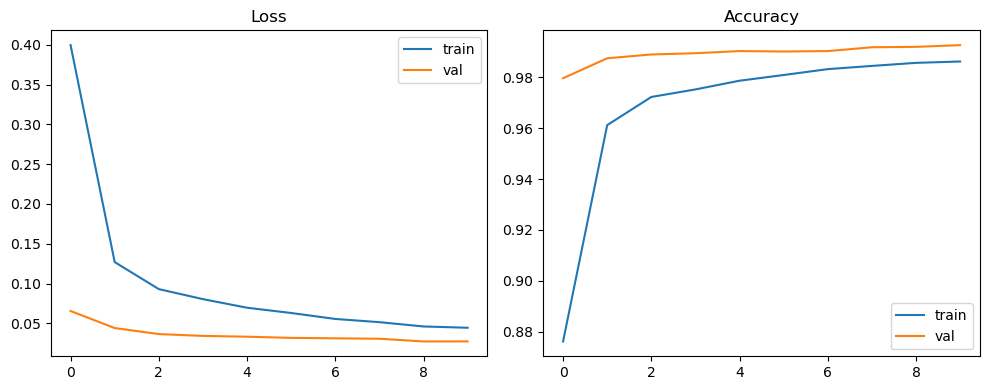

In [ ]:
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.plot(history.history["loss"], label="train")
plt.plot(history.history["val_loss"], label="val")
plt.title("Loss"); plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history["accuracy"], label="train")
plt.plot(history.history["val_accuracy"], label="val")
plt.title("Accuracy"); plt.legend()

plt.tight_layout(); plt.show()


Validation loss drops smoothly and stays just below training loss (dropout makes train noisier), while both accuracies rise and stay close—validation even slightly higher early on. This points to good fit and no overfitting; the model converged well within 10 epochs.

## L08: Learning Curves

### The Generalization Error, Over- and Underfitting, Early Stopping, and Optimal Capacity

In this exercise, we need to explain all important overall concepts in training. Let's begin with Figure 5.3 from Deep Learning (Ian Goodfellow, et. al. [DL]), which pretty much sums it all up

<img src="https://itundervisning.ase.au.dk/SWMAL/L08/Figs/dl_generalization_error.png" alt="WARNING: could not get image from server." style="height:500px">


### Qa) The Generalization Error

Write a detailed description of figure 5.3 (above) for your hand-in.
 
All concepts in the figure must be explained 

* training/generalization error, 
* underfit/overfit zone, 
* optimal capacity, 
* generalization gab, 
* and the two axes: x/capacity, y/error.

### _ANSWER_
The graph in figure 5.3 displays a blue and a green curve. The blue dashed line shows the amount of errors in the training and shows how well the model fits the training data. The green curve is the generalization error (test error), which is how well it performs on unseen data.
The X-axis on the graph shows the capacity of the model and the Y-axis shows error.

The graph is split into 3 zones. A underfitting zone, optimal capacity and an overfitting zone.

The underfitting zone in the left side shows that the capacity is very low, which indicates that the model is simple. Training error is high and test error is also very high. This underfitting is where the model haven't picked up on the data pattern just yet. It could need more training.

The overfitting zone on the right side whows the training error is low, and test error is much higher. This overfitting is when the model fits the training data perfectly. When test error is high, it cannot really predict on new data very well. It probably memoizes the data set.

The optimal capacity at the red line, is when the model knows just enough to know the pattern of the training data, but not enough to have it memoized. 

The generalization gap is the space between training error and test/generalization error in the graph. Its defined by $Generalization_gap = Test_error - Training_error$.
It shows how worse our model performs on unseen data, compared to the data that was used to train the model. If the gap is small, then the model generalizes well, which means that it learned the patterns in the training data. If the gap is large, then it is overfitting, meaning that it probably has memoized the training data.

The two axes, x and y, is respectively the model capacity and the error.
Model capacity measures how complex or flexible our model is. When we move along the axis, the model get more capacity, which means more layers, parameters and fit the training data more precisely. But as mentioned before, the model could also begin to memorize the data.
Left is the simple model, right is the genius model that remembers everything.
The Y-axis is error. The higher the error rate is, the more wrong it is. Lower is better. As the capacity increases, the training errors decreases. In the start our model learns the data and the patterns, but if we continue the model overfits and errors starts to increase again.


[Source (chatGPT)](https://chatgpt.com/share/69047c07-f5a0-8008-8dbf-83f04627ebe7)

### Qb Learning Curves

Next, produce a loss vs epoch graph ala (from `04_training_linear_models.ipynb` [GITHOML]) 

<img src="https://itundervisning.ase.au.dk/SWMAL/L08/Figs/training_curve.png" alt="WARNING: could not get image from server.">


for your linear regressor, `MyLinReg`, from an earlier lesson. You need a function 

>```LossHistory()```

on your regressor class, that accumulates the internally calculated $J$'s. Once `LossHistory` is ready, plot it using the code below.

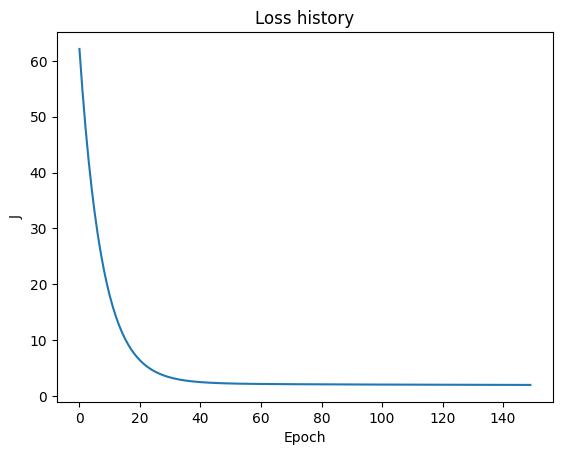

OK


In [ ]:
import numpy as np

class MyLinReg():
    def __init__(self, eta0=0.05, max_iter=300, tol=1e-8, n_iter_no_change=30, verbose=True,
                 solver="gd", batch_size=1, shuffle=True, random_state=None):
        self.eta0 = eta0
        self.max_iter = max_iter
        self.tol = tol
        self.n_iter_no_change = n_iter_no_change
        self.verbose = verbose
        self.solver = solver
        self.batch_size = batch_size
        self.shuffle = shuffle
        self.random_state = random_state
        self.w_ = None
        self.errors_ = []

    def __str__(self):
        return f"MyLinReg(eta0={self.eta0}, max_iter={self.max_iter})"
    
    def _add_bias(self, X): # bias function where the column of 1's is added to X
        return np.c_[np.ones((X.shape[0], 1)), X]

    def _cost(self, X, y, w): # cost function 
        error = X @ w - y
        return 0.5 * np.sum(error ** 2)

    def fit(self, X, y):
        X = np.asarray(X)
        y = np.asarray(y).ravel()
        Xb = self._add_bias(X)
        n_samples, n_features = Xb.shape
        self.w_ = np.zeros(n_features)

        rng = np.random.default_rng(self.random_state)

        # Batch gradient descent - minimizes the cost function over all samples
        if self.solver == "gd":
            for i in range(self.max_iter):
                error = Xb @ self.w_ - y
                grad = Xb.T @ error
                J = 0.5 * np.sum(error ** 2)
                self.errors_.append(J)
                self.w_ -= self.eta0 * grad # Gradient descent step

                if self.verbose and (i % 10 == 0 or i == self.max_iter - 1):
                    print(f"Iter {i+1:03d}: J={J:.6f}, |grad|={np.linalg.norm(grad):.4f}")

        # Stochastic gradient descent
        else:
            bs = max(1, int(self.batch_size))
            idx = np.arange(n_samples)
            for epoch in range(self.max_iter):
                if self.shuffle:
                    rng.shuffle(idx)
                for s in range(0, n_samples, bs):
                    j = idx[s:s+bs]
                    err_j = Xb[j] @ self.w_ - y[j]
                    grad_j = Xb[j].T @ err_j
                    self.w_ -= self.eta0 * grad_j

                J = 0.5 * np.sum((Xb @ self.w_ - y) ** 2)
                self.errors_.append(J) # log cost (once per epoch)

                # verbose output 
                if self.verbose and (epoch % 10 == 0 or epoch == self.max_iter - 1):
                    print(f"Epoch {epoch+1:03d}: J={J:.6f}")

        self.intercept_ = self.w_[0]
        self.coef_ = self.w_[1:]
        return self

    def predict(self, X): # returns predictions
        Xb = self._add_bias(X)
        return Xb @ self.w_

    def score(self, X, y): # R^2 score
        y = np.asarray(y).ravel()
        y_pred = self.predict(X)
        ss_res = np.sum((y - y_pred)**2)
        ss_tot = np.sum((y - np.mean(y))**2)
        return 1 - ss_res/ss_tot if ss_tot != 0 else 0.0

    def mse(self, X, y): # MSE function
        error = self.predict(X) - y
        return np.mean(error ** 2)
    
    def LossHistory(self):
        return np.array(self.errors_, dtype=float)

def GenerateData():
    X = np.array([[8.34044009e-01],[1.44064899e+00],[2.28749635e-04],[6.04665145e-01]])
    y = np.array([5.97396028, 7.24897834, 4.86609388, 3.51245674])
    return X, y

# Train and plot a learning curve (batch GD)
X, y = GenerateData()

# r = MyLinReg()
r = MyLinReg(eta0=0.01, max_iter=150, verbose=False, solver="gd").fit(X, y)


# assert False, "TODO: fit on some data here.."

h = r.LossHistory()

# Plot of J vs. epoch (or perhaps iteration)...

%matplotlib inline
import matplotlib.pyplot as plt

fig, ax = plt.subplots()
plt.plot(h)

ax.set_title("Loss history")
ax.set_xlabel("Epoch")
ax.set_ylabel("J")

zoom_axis = False
if zoom_axis:
    limits_x = ax.get_xlim()
    limits_y = ax.get_ylim()
    ax.set_ylim([0, limits_y[1]/10]) # zoom on y axis
    
plt.show()

print("OK")

### Qc)  Early Stopping

Then implement ___early stopping___, in your `MyLinReg` estimator. Below is a graphical view of early stopping similar to Figure 4-20 p.162 [HOML] (for a non-linear model?)

<img src="https://itundervisning.ase.au.dk/SWMAL/L08/Figs/early_stopping.png" alt="WARNING: could not get image from server.">

Write an explanation of the early stopping concept in text, implement it in your linear regressor and write some test/demo code, that via some learning-curve graphs demonstrates how it works when training your linear regressor in both _batch-gradient descent_ and 
_stochastic gradient descent_ modes.

In [ ]:
assert False, "TODO: implement early stopping

### Qd:  [OPTIONAL]  Using a Polynomial Regressor to Produce an Error-vs-Capacity Graph

Finally, create a polynomial estimator based on your `MyLinReg`, see details of
how to expend a linear regressor to a polynomial fitting in [HOLM] or in

> https://scikit-learn.org/stable/auto_examples/model_selection/plot_underfitting_overfitting.html
 
that contains most of the code you will need. 
 
With a polynomial regressor, you should be able to reproduce a graph similar to Figure 5.3 from Deep Learning [DL], where you notice that the _x-axis_ is capacity and not _epoch_ as the learning curves you just produced in Qb/c.

In [ ]:
assert False "TODO: implement a polynomial-fit pipeline, and create an Error-vs-Capacity plot..

pipeline = Pipeline([
      ("polynomial_features", polynomial_features),
      ("linear_regression",   MyLinReg())
  ])


### Qe Conclusion

Sum it all up in a nice, well-written conclusion.

## L09: Hyperparameters and Gridsearch 

When instantiating a Scikit-learn model in python most or all constructor parameters have _default_ values. These values are not part of the internal model and are hence called ___hyperparameters___---in contrast to _normal_ model parameters, for example the neuron weights, $\mathbf w$, for an `MLP` model.

### Manual Tuning Hyperparameters

Below is an example of the python constructor for the support-vector classifier `sklearn.svm.SVC`, with say the `kernel` hyperparameter having the default value `'rbf'`. If you should choose, what would you set it to other than `'rbf'`? 

```python
class sklearn.svm.SVC(
    C=1.0, 
    kernel=’rbf’, 
    degree=3,
    gamma=’auto_deprecated’, 
    coef0=0.0, 
    shrinking=True, 
    probability=False, 
    tol=0.001, 
    cache_size=200, 
    class_weight=None, 
    verbose=False, 
    max_iter=-1, 
    decision_function_shape=’ovr’, 
    random_state=None
  )
```  

The default values might be a sensible general starting point, but for your data, you might want to optimize the hyperparameters to yield a better result. 

To be able to set `kernel` to a sensible value you need to go into the documentation for the `SVC` and understand what the kernel parameter represents, and what values it can be set to, and you need to understand the consequences of setting `kernel` to something different than the default...and the story repeats for every other hyperparameter!

### Brute Force  Search

An alternative to this structured, but time-consuming approach, is just to __brute-force__ a search of interesting hyperparameters, and  choose the 'best' parameters according to a fit-predict and some score, say 'f1'. 

<img src="https://itundervisning.ase.au.dk/SWMAL/L09/Figs/gridsearch.png"  alt="WARNING: could not get image from server."  style="width:350px">
<small><em>
    <center> Conceptual graphical view of grid search for two distinct hyperparameters. </center> 
    <center> Notice that you would normally search hyperparameters like `alpha` with an exponential range, say [0.01, 0.1, 1, 10] or similar.</center>
</em></small>

Now, you just pick out some hyperparameters, that you figure are important, set them to a suitable range, say

```python
    'kernel':('linear', 'rbf'), 
    'C':[1, 10]
```
and fire up a full (grid) search on this hyperparameter set, that will try out all your specified combination of `kernel` and `C` for the model, and then prints the hyperparameter set with the highest score...

The demo code below sets up some of our well known 'hello-world' data and then run a _grid search_ on a particular model, here a _support-vector classifier_ (SVC)

Other models and datasets  ('mnist', 'iris', 'moon') can also be examined.

### Qa Explain GridSearchCV

There are two code cells below: 1) function setup, 2) the actual grid-search.

Review the code cells and write a __short__ summary. Mainly focus on __cell 2__, but dig into cell 1 if you find it interesting (notice the use of local-function, a nifty feature in python).
  
In detail, examine the lines:  
  
```python
grid_tuned = GridSearchCV(model, tuning_parameters, ..
grid_tuned.fit(X_train, y_train)
..
FullReport(grid_tuned , X_test, y_test, time_gridsearch)
```
and write a short description of how the `GridSeachCV` works: explain how the search parameter set is created and the overall search mechanism is functioning (without going into too much detail).

What role does the parameter `scoring='f1_micro'` play in the `GridSearchCV`, and what does `n_jobs=-1` mean? 

In [ ]:
# TODO: Qa, code review..cell 1) function setup

from time import time
import numpy as np
import sys

from sklearn import svm
from sklearn.linear_model import SGDClassifier

from sklearn.model_selection import GridSearchCV, RandomizedSearchCV, train_test_split
from sklearn.metrics import classification_report, f1_score
from sklearn import datasets

from libitmal import dataloaders as itmaldataloaders # Needed for load of iris, moon and mnist

currmode="N/A" # GLOBAL var!

def SearchReport(model): 
    
    def GetBestModelCTOR(model, best_params):
        def GetParams(best_params):
            ret_str=""          
            for key in sorted(best_params):
                value = best_params[key]
                temp_str = "'" if str(type(value))=="<class 'str'>" else ""
                if len(ret_str)>0:
                    ret_str += ','
                ret_str += f'{key}={temp_str}{value}{temp_str}'  
            return ret_str          
        try:
            param_str = GetParams(best_params)
            return type(model).__name__ + '(' + param_str + ')' 
        except:
            return "N/A(1)"
        
    print("\nBest model set found on train set:")
    print()
    print(f"\tbest parameters={model.best_params_}")
    print(f"\tbest '{model.scoring}' score={model.best_score_}")
    print(f"\tbest index={model.best_index_}")
    print()
    print(f"Best estimator CTOR:")
    print(f"\t{model.best_estimator_}")
    print()
    try:
        print(f"Grid scores ('{model.scoring}') on development set:")
        means = model.cv_results_['mean_test_score']
        stds  = model.cv_results_['std_test_score']
        i=0
        for mean, std, params in zip(means, stds, model.cv_results_['params']):
            print("\t[%2d]: %0.3f (+/-%0.03f) for %r" % (i, mean, std * 2, params))
            i += 1
    except:
        print("WARNING: the random search do not provide means/stds")
    
    global currmode                
    assert "f1_micro"==str(model.scoring), f"come on, we need to fix the scoring to be able to compare model-fits! Your scoreing={str(model.scoring)}...remember to add scoring='f1_micro' to the search"   
    return f"best: dat={currmode}, score={model.best_score_:0.5f}, model={GetBestModelCTOR(model.estimator,model.best_params_)}", model.best_estimator_ 

def ClassificationReport(model, X_test, y_test, target_names=None):
    assert X_test.shape[0]==y_test.shape[0]
    print("\nDetailed classification report:")
    print("\tThe model is trained on the full development set.")
    print("\tThe scores are computed on the full evaluation set.")
    print()
    y_true, y_pred = y_test, model.predict(X_test)                 
    print(classification_report(y_true, y_pred, target_names=target_names))
    print()
    
def FullReport(model, X_test, y_test, t):
    print(f"SEARCH TIME: {t:0.2f} sec")
    beststr, bestmodel = SearchReport(model)
    ClassificationReport(model, X_test, y_test)    
    print(f"CTOR for best model: {bestmodel}\n")
    print(f"{beststr}\n")
    return beststr, bestmodel
    
def LoadAndSetupData(mode, test_size=0.3):
    assert test_size>=0.0 and test_size<=1.0
    
    def ShapeToString(Z):
        n = Z.ndim
        s = "("
        for i in range(n):
            s += f"{Z.shape[i]:5d}"
            if i+1!=n:
                s += ";"
        return s+")"

    global currmode
    currmode=mode
    print(f"DATA: {currmode}..")
    
    if mode=='moon':
        X, y = itmaldataloaders.MOON_GetDataSet(n_samples=5000, noise=0.2)
        itmaldataloaders.MOON_Plot(X, y)
    elif mode=='mnist':
        X, y = itmaldataloaders.MNIST_GetDataSet(load_mode=0)
        if X.ndim==3:
            X=np.reshape(X, (X.shape[0], -1))
    elif mode=='iris':
        X, y = itmaldataloaders.IRIS_GetDataSet()
    else:
        raise ValueError(f"could not load data for that particular mode='{mode}', only 'moon'/'mnist'/'iris' supported")
        
    print(f'  org. data:  X.shape      ={ShapeToString(X)}, y.shape      ={ShapeToString(y)}')

    assert X.ndim==2
    assert X.shape[0]==y.shape[0]
    assert y.ndim==1 or (y.ndim==2 and y.shape[1]==0)    
    
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=0, shuffle=True
    )
    
    print(f'  train data: X_train.shape={ShapeToString(X_train)}, y_train.shape={ShapeToString(y_train)}')
    print(f'  test data:  X_test.shape ={ShapeToString(X_test)}, y_test.shape ={ShapeToString(y_test)}')
    print()
    
    return X_train, X_test, y_train, y_test

def TryKerasImport(verbose=True):
    
    kerasok = True
    try:
        import keras as keras_try
    except:
        kerasok = False

    tensorflowkerasok = True
    try:
        import tensorflow.keras as tensorflowkeras_try
    except:
        tensorflowkerasok = False
        
    ok = kerasok or tensorflowkerasok
    
    if not ok and verbose:
        if not kerasok:
            print("WARNING: importing 'keras' failed", file=sys.stderr)
        if not tensorflowkerasok:
            print("WARNING: importing 'tensorflow.keras' failed", file=sys.stderr)

    return ok
    
print(f"OK(function setup" + ("" if TryKerasImport() else ", hope MNIST loads works because it seems you miss the installation of Keras or Tensorflow!") + ")")

In [ ]:
# TODO: Qa, code review..cell 2) the actual grid-search

# Setup data
X_train, X_test, y_train, y_test = LoadAndSetupData(
    'iris')  # 'iris', 'moon', or 'mnist'

# Setup search parameters
model = svm.SVC(
    gamma=0.001
)  # NOTE: gamma="scale" does not work in older Scikit-learn frameworks,
# FIX:  replace with model = svm.SVC(gamma=0.001)

tuning_parameters = {
    'kernel': ('linear', 'rbf'), 
    'C': [0.1, 1, 10]
}

CV = 5
VERBOSE = 0

# Run GridSearchCV for the model
grid_tuned = GridSearchCV(model,
                          tuning_parameters,
                          cv=CV,
                          scoring='f1_micro',
                          verbose=VERBOSE,
                          n_jobs=-1)

start = time()
grid_tuned.fit(X_train, y_train)
t = time() - start

# Report result
b0, m0 = FullReport(grid_tuned, X_test, y_test, t)
print('OK(grid-search)')

### Qb Hyperparameter Grid Search using an SDG classifier

Now, replace the `svm.SVC` model with an `SGDClassifier` and a suitable set of the hyperparameters for that model.

You need at least four or five different hyperparameters from the `SGDClassifier` in the search-space before it begins to take considerable compute time doing the full grid search.

So, repeat the search with the `SGDClassifier`, noticing that it may return a result in a few seconds, even for a larges hyperparameter search-space, due to the low dimensionality and low number of samples in the iris dataset (for larger datasets it can run for hours or days!) 

In [ ]:
# TODO: grid search
assert False, "TODO: make a grid search on the SDG classifier.."

### Qc Hyperparameter Random  Search using an SDG classifier

Now, add code to run a `RandomizedSearchCV` instead.

<img src="https://itundervisning.ase.au.dk/SWMAL/L09/Figs/randomsearch.png" alt="WARNING: could not get image from server."  style="width:350px" >
<small><em>
    <center> Conceptual graphical view of randomized search for two distinct hyperparameters. </center> 
</em></small>

Use these default parameters for the random search, similar to the default parameters for the grid search

```python
random_tuned = RandomizedSearchCV(
    model, 
    tuning_parameters, 
    n_iter=20, 
    random_state=42, 
    cv=CV, 
    scoring='f1_micro', 
    verbose=VERBOSE, 
    n_jobs=-1
)
```

but with the two new parameters, `n_iter` and `random_state` added. Since the search-type is now random, the `random_state` gives sense, but essential to random search is the new `n_iter` parameter.

So: investigate the `n_iter` parameter...in code and write a conceptual explanation  in text.

Comparison of time (seconds) to complete `GridSearch` versus `RandomizedSearchCV`, does not necessarily give any sense, if your grid search completes in a few seconds (as for the iris tiny-data). You need a search that runs for minutes, hours, or days.

But you could compare the best-tuned parameter set and best scoring for the two methods. Is the random search best model close to the grid search?  

In [ ]:
# TODO:
assert False, "implement a random search for the SGD classifier.."

### Qd MNIST Search Quest II

Finally, a search-quest competition: __who can find the best model+hyperparameters for the MNIST dataset?__

You change to the MNIST data by calling `LoadAndSetupData('mnist')`, and this is a completely other ball-game that the iris _tiny-data_: it's much larger (but still far from _big-data_)!

* You might opt for the exhaustive grid search, or use the faster but-less optimal random search...your choice. 

* You are free to pick any classifier in Scikit-learn, even algorithms we have not discussed yet---__except Neural Networks and KNeighborsClassifier!__. 

* Keep the score function at `f1_micro`, otherwise, we will be comparing 'æbler og pærer'. 

* And, you may also want to scale your input data for some models to perform better.

* __REMEMBER__, DO NOT USE any Neural Network models. This also means not to use any `Keras` or `Tensorflow` models...since they outperform most other models, and there are also too many examples on the internet to cut-and-paste from!

Check your result by printing the first _return_ value from `FullReport()` 
```python 
b1, m1 = FullReport(random_tuned , X_test, y_test, time_randomsearch)
print(b1)
```
that will display a result like
```
best: dat=mnist, score=0.90780, model=SGDClassifier(alpha=1.0,eta0=0.0001,learning_rate='invscaling')
```
and paste your currently best model into the message box, for ITMAL group 09 like
```
Grp09: best: dat=mnist, score=0.90780, model=SGDClassifier(alpha=1.0,eta0=0.0001,learning_rate='invscaling')

Grp09: CTOR for best model: SGDClassifier(alpha=1.0, average=False, class_weight=None, early_stopping=False,
              epsilon=0.1, eta0=0.0001, fit_intercept=True, l1_ratio=0.15,
              learning_rate='invscaling', loss='hinge', max_iter=1000,
              n_iter_no_change=5, n_jobs=None, penalty='l2', power_t=0.5,
              random_state=None, shuffle=True, tol=0.001,
              validation_fraction=0.1, verbose=0, warm_start=False)
```
              
on Brightspace: "L09: Regularisering, optimering og søgning" | "Qd MNIST Search Quest II"

> https://itundervisning.ase.au.dk/Searchquest/index.php

and, check if your score (for MNIST) is better than the currently best score. Republish if you get a better score than your own previously best. Deadline for submission of scores is the same as the deadline for the O3 journal handin.

Remember to provide an ITMAL group name manually, so we can identify a winner: the 1. st price is  cake! 

For the journal hand-in, report your progress in scoring choosing different models, hyperparameters to search and how you might need to preprocess your data...and note, that the journal will not be accepted unless it contains information about Your results published on the Brightspace 'Search Quest II' page!

In [ ]:
# TODO:(in code and text..)
assert False, "participate in the Search Quest---remember to publish your result(s) on Brightspace."

## L10: Sprogmodeller/NanoGPT